In [1]:
pip install -r requirements.txt

  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/98/af/7be05277859a7bc399da8ba68b88c96b27b48740b6cf49688899c6eb4176/pandas-2.3.3-cp39-cp39-win_amd64.whl.metadata
  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/ea/2b/7fc9f4e7ae5b507c1a3a21f0f15ed03e794c1242ea8a242ac158beb56034/numpy-2.0.2-cp39-cp39-win_amd64.whl.metadata
  Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl.metadata (59 kB)
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/57/68/c2feb4667adbf882ffa4b3e0ac9967f848980d9f8b5bebd86644aa67ce6a/matplotlib-3.9.4-cp39-cp39-win_amd64.whl.metadata
  Using cached matplotlib-3.9.4-cp39-cp39-win_amd64.whl.metadata (11 kB)
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Using cached seaborn-0.13.2-py3-none-an


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
!pip install pillow-heif


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


In [5]:
import tensorflow as tf
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Hilangkan log warning CPU

print(f"TensorFlow Version: {tf.__version__}") # Harus 2.10.x
print(f"Python Version: {sys.version}") # Harus 3.9.x

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ SUKSES! GPU Terdeteksi: {gpus}")
    print("RTX 4060 Anda siap digunakan untuk training.")
else:
    print("❌ GAGAL. Masih menggunakan CPU.")

TensorFlow Version: 2.20.0
Python Version: 3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]
❌ GAGAL. Masih menggunakan CPU.


In [1]:
import os
from PIL import Image
from tqdm import tqdm
import pandas as pd

# --- KHUSUS HEIC ---
# Daftarkan pembaca HEIC agar Image.open() bisa membacanya
try:
    from pillow_heif import register_heif_opener
    register_heif_opener()
    print("Support HEIC berhasil diaktifkan.")
except ImportError:
    print("Library 'pillow-heif' belum terinstall. Jalankan '!pip install pillow-heif' dulu.")

# ==========================================
# KONVERSI SEMUA DATA (TERMASUK HEIC) KE PNG
# ==========================================

output_base_dir = 'DENGAN LEMPUK PNG'  # Folder tujuan
print(f"\nMemulai konversi gambar ke PNG...")
print(f"Data akan disimpan di: {output_base_dir}")

new_data_list = []
error_files = []

# Menggunakan tqdm untuk progress bar
for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Converting"):
    src_path = row['filepath']
    label = row['label']  
    
    # 1. Persiapan Folder Tujuan
    parts = label.split() 
    variation_folder = parts[0] # V1
    quality_folder = parts[1]   # FRESH
    
    target_folder = os.path.join(output_base_dir, quality_folder, variation_folder)
    os.makedirs(target_folder, exist_ok=True)
    
    # 2. Nama File Baru (.png)
    file_name = os.path.basename(src_path)
    name_without_ext = os.path.splitext(file_name)[0]
    new_filename = f"{name_without_ext}.png"
    dst_path = os.path.join(target_folder, new_filename)
    
    # 3. Proses Konversi
    try:
        # Image.open sekarang sudah bisa buka HEIC karena register_heif_opener()
        with Image.open(src_path) as img:
            
            # Convert ke RGB 
            # (Penting: HEIC/PNG bisa punya alpha channel/transparansi, 
            # untuk deep learning amannya dipaksa ke RGB 3-channel)
            img = img.convert('RGB')
            
            # Simpan sebagai PNG
            img.save(dst_path, 'PNG')
            
            # Masukkan path baru ke list
            new_data_list.append({'filepath': dst_path, 'label': label})
            
    except Exception as e:
        print(f"\n[ERROR] Gagal: {src_path} | Error: {e}")
        error_files.append(src_path)

# ==========================================
# UPDATE DATAFRAME
# ==========================================
df_png = pd.DataFrame(new_data_list)
df = df_png # Timpa df lama dengan data PNG baru

print("\n" + "="*40)
print("KONVERSI SELESAI")
print("="*40)
print(f"Total Asli  : {len(df) + len(error_files)}")
print(f"Berhasil PNG: {len(df_png)}")
print(f"Gagal       : {len(error_files)}")

if len(error_files) > 0:
    print("Contoh file gagal:", error_files[:3])

ModuleNotFoundError: No module named 'tqdm'

## LOAD DATA

In [2]:
# ==========================================
# 1. MOUNT GOOGLE DRIVE & PERSIAPAN DATA
# ==========================================


# --- KONFIGURASI FOLDER ---
# Pastikan path ini sesuai dengan di Drive Anda
base_dir = 'DENGAN LEMPUK PNG'

# List Variasi dan Kualitas sesuai struktur folder Anda
qualities = ['FRESH', "SPOILED"]
variations = ['V1', 'V2', 'V3', 'V4']
print("Sedang memindai file dan membuat label...")

data_list = []

# Loop untuk membaca file dari struktur folder
for quality in qualities:

  for variation in variations:
      # Menyusun path: .../TANPA LEMPUK/FRESH/Variasi 1
      folder_path = os.path.join(base_dir, quality, variation)
        
      if os.path.exists(folder_path):
          files = os.listdir(folder_path)
          for file_name in files:
              if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.heic')):
                  # Membuat Label: "Variasi 1 FRESH", dst.
                  label_name = f"{variation} {quality}" 
                  full_path = os.path.join(folder_path, file_name)
                  data_list.append({'filepath': full_path, 'label': label_name})
      else:
          print(f"Warning: Folder tidak ditemukan -> {folder_path}")

# Konversi ke DataFrame
df = pd.DataFrame(data_list)
print(f"\nTotal Data Ditemukan: {len(df)}")
print(f"Jumlah Kelas: {df['label'].nunique()}")

# Cek distribusi data
print("\nJumlah data per kelas:")
print(df['label'].value_counts())

Sedang memindai file dan membuat label...

Total Data Ditemukan: 160
Jumlah Kelas: 8

Jumlah data per kelas:
label
V1 FRESH      20
V2 FRESH      20
V3 FRESH      20
V4 FRESH      20
V1 SPOILED    20
V2 SPOILED    20
V3 SPOILED    20
V4 SPOILED    20
Name: count, dtype: int64


In [3]:

# Konversi ke DataFrame
df = pd.DataFrame(data_list)
print(f"\nTotal Data Awal: {len(df)}")
print("Distribusi Awal:")
print(df['label'].value_counts())

# ==========================================
# 2. PROSES UNDERSAMPLING
# ==========================================
print("\n--- Memulai Proses Undersampling ---")

# 1. Cari jumlah sampel terkecil di antara semua kelas
min_sample = df['label'].value_counts().min()
print(f"Jumlah sampel terendah (target undersampling): {min_sample}")

# 2. Lakukan Undersampling
# Groupby label, lalu ambil sample sejumlah 'min_sample' dari setiap grup
df = df.groupby('label', group_keys=False).apply(lambda x: x.sample(min_sample, random_state=42))

# Reset index agar rapi
df = df.reset_index(drop=True)

# 3. Cek Hasil Balancing
print(f"\nTotal Data Setelah Undersampling: {len(df)}")
print("Distribusi Setelah Undersampling:")
print(df['label'].value_counts())


Total Data Awal: 160
Distribusi Awal:
label
V1 FRESH      20
V2 FRESH      20
V3 FRESH      20
V4 FRESH      20
V1 SPOILED    20
V2 SPOILED    20
V3 SPOILED    20
V4 SPOILED    20
Name: count, dtype: int64

--- Memulai Proses Undersampling ---
Jumlah sampel terendah (target undersampling): 20

Total Data Setelah Undersampling: 160
Distribusi Setelah Undersampling:
label
V1 FRESH      20
V1 SPOILED    20
V2 FRESH      20
V2 SPOILED    20
V3 FRESH      20
V3 SPOILED    20
V4 FRESH      20
V4 SPOILED    20
Name: count, dtype: int64


C:\Users\Azvaden\AppData\Local\Temp\ipykernel_12456\1600019215.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('label', group_keys=False).apply(lambda x: x.sample(min_sample, random_state=42))


In [6]:
def visualize_split(train_df, val_df, test_df):
    # ==========================================
    # 1. PIE CHART: Overall Percentage
    # ==========================================
    sizes = [len(train_df), len(val_df), len(test_df)]
    labels = ['Training (70%)', 'Validation (20%)', 'Testing (10%)']
    colors = ['#4CAF50', '#FFC107', '#2196F3']  # Green, Yellow, Blue
    explode = (0.05, 0, 0)  # Slightly separate the Training slice

    plt.figure(figsize=(18, 6))

    # Subplot 1: Pie Chart
    plt.subplot(1, 2, 1)
    plt.pie(
        sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=140, pctdistance=0.85, explode=explode, shadow=True
    )

    # Create a center circle (Donut Chart) for a more aesthetic look
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.title('Overall Data Split Proportion', fontsize=14, fontweight='bold')
    plt.axis('equal')

    # ==========================================
    # 2. STACKED BAR CHART: Distribution per Class
    # ==========================================
    # Count samples per class for each split
    train_counts = train_df['label'].value_counts().sort_index()
    val_counts = val_df['label'].value_counts().sort_index()
    test_counts = test_df['label'].value_counts().sort_index()

    # Combine counts into a single DataFrame for plotting
    df_counts = pd.DataFrame({
        'Training': train_counts,
        'Validation': val_counts,
        'Testing': test_counts
    })

    # Subplot 2: Stacked Bar Chart
    plt.subplot(1, 2, 2)

    # Plot
    df_counts.plot(kind='bar', stacked=True, color=colors, ax=plt.gca(), width=0.8)

    plt.title('Class-wise Data Distribution (Stratified)', fontsize=14, fontweight='bold')
    plt.xlabel('Class Label')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Dataset')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Show detailed table
    print("\nDetailed Sample Count per Class:")
    print(df_counts)


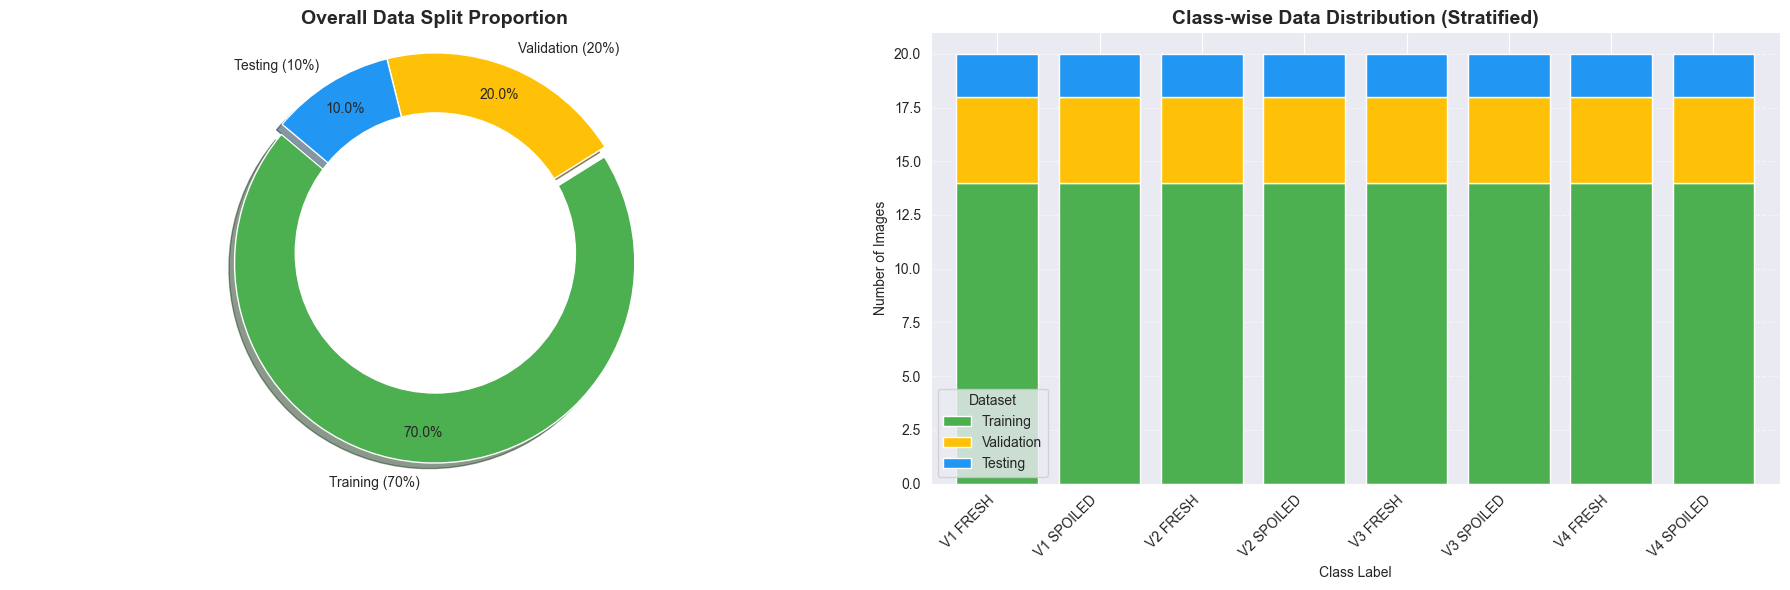


Detailed Sample Count per Class:
            Training  Validation  Testing
label                                    
V1 FRESH          14           4        2
V1 SPOILED        14           4        2
V2 FRESH          14           4        2
V2 SPOILED        14           4        2
V3 FRESH          14           4        2
V3 SPOILED        14           4        2
V4 FRESH          14           4        2
V4 SPOILED        14           4        2

--- Pembagian Data ---
Training   : 112 (70.0%)
Validation : 32 (20.0%)
Test       : 16 (10.0%)


In [7]:
# ==========================================
# 2. SPLITTING DATA (70% Train, 20% Val, 10% Test)
# ==========================================
# Langkah 1: Pisahkan 70% untuk Training
train_df, temp_df = train_test_split(df, train_size=0.7, stratify=df['label'], random_state=42)

# Langkah 2: Pisahkan sisanya (Temp) menjadi Val dan Test
# Val mengambil 2/3 dari Temp (sehingga totalnya 20% dari keseluruhan)
val_df, test_df = train_test_split(temp_df, train_size=2/3, stratify=temp_df['label'], random_state=42)

visualize_split(train_df, val_df, test_df)

print(f"\n--- Pembagian Data ---")
print(f"Training   : {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation : {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test       : {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

## AUGMENTASI

In [8]:


# ==========================================
# 3. DATA GENERATOR
# ==========================================
IMG_SIZE = (150, 150)
BATCH_SIZE = 32


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=60,
    width_shift_range=0.35,
    height_shift_range=0.35,
    shear_range=0.35,
    zoom_range=(0.7, 1.4),
    horizontal_flip=True,
    vertical_flip=False,            
    brightness_range=(0.6, 1.4),
    channel_shift_range=30.0,
    fill_mode='reflect',             # sering lebih natural daripada 'nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Train Generator
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)

# Validation Generator
val_gen = val_test_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# Test Generator (Shuffle False agar urutan prediksi sesuai label asli untuk evaluasi)
test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print(class_names)

Found 112 validated image filenames belonging to 8 classes.
Found 32 validated image filenames belonging to 8 classes.
Found 16 validated image filenames belonging to 8 classes.
['V1 FRESH', 'V1 SPOILED', 'V2 FRESH', 'V2 SPOILED', 'V3 FRESH', 'V3 SPOILED', 'V4 FRESH', 'V4 SPOILED']


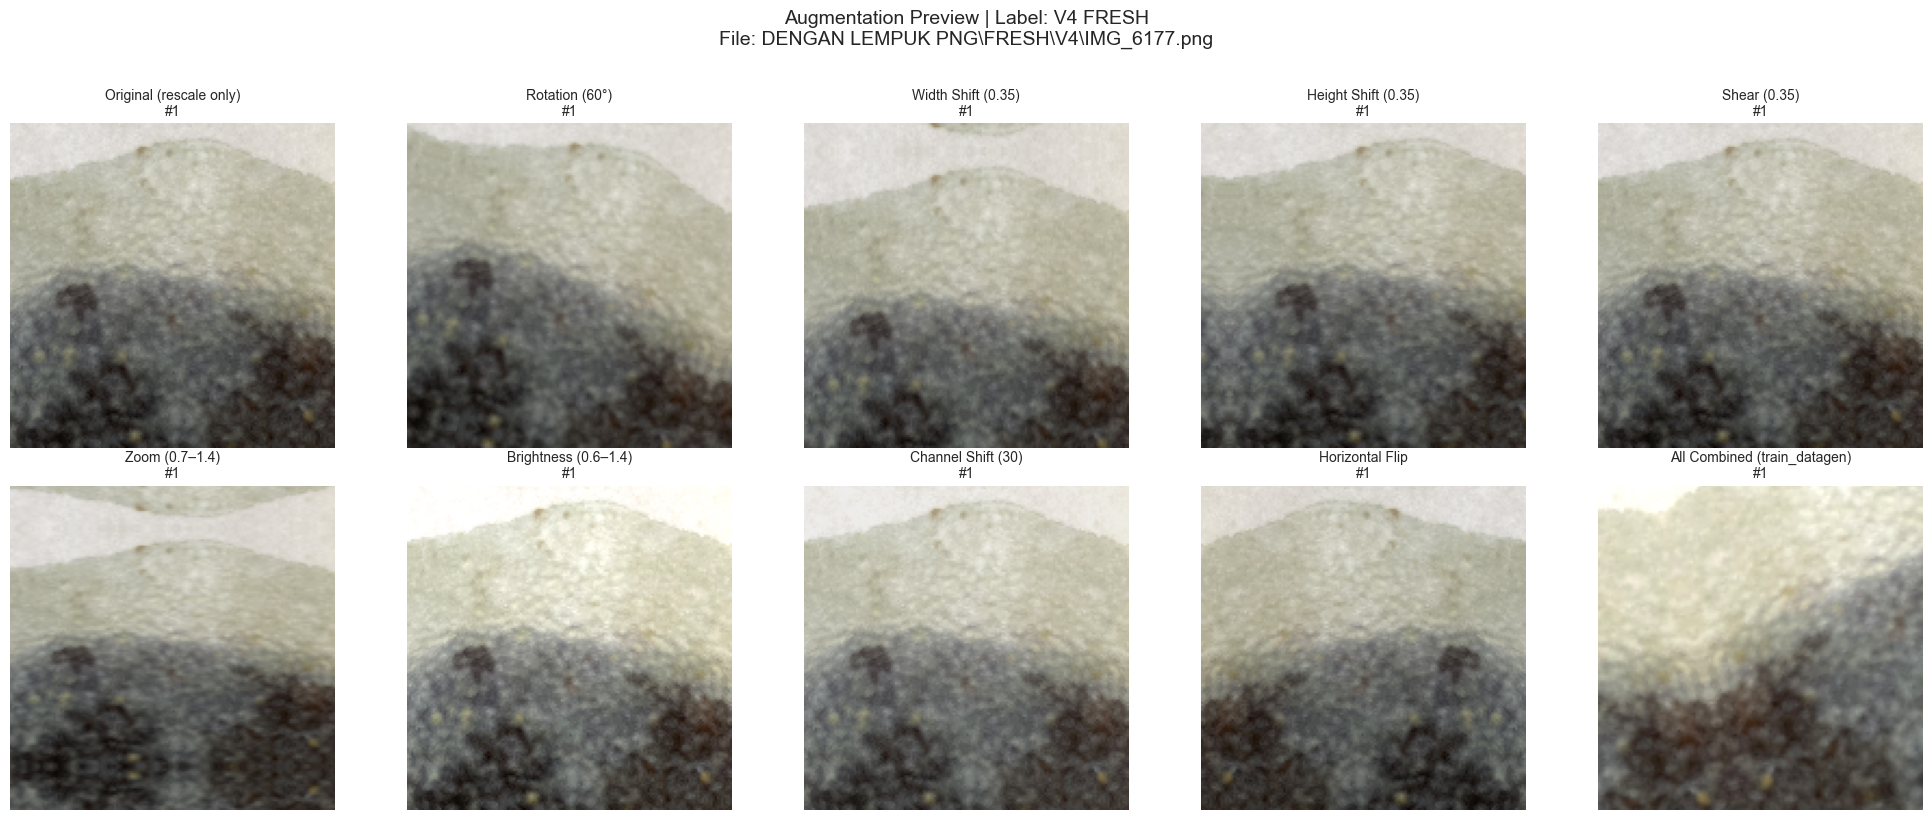

In [9]:
import numpy as np
import math
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

def _clip_for_display(img):
    # img is float, typically in [0,1], but augmentation can push outside
    return np.clip(img, 0.0, 1.0)

def visualize_specific_augmentations(
    dataframe,
    img_size=(150, 150),
    n_examples=1,
    seed=42
):
    # 1) Pick one sample
    sample_row = dataframe.sample(1, random_state=seed).iloc[0]
    img_path = sample_row["filepath"]
    label = sample_row["label"]

    # 2) Load image (no rescale yet)
    img = load_img(img_path, target_size=img_size)
    x = img_to_array(img)  # 0..255 float32
    x = x.reshape((1,) + x.shape)  # (1, H, W, 3)

    # 3) Define augmentations (match your current training settings)
    aug_types = {
        "Original (rescale only)": ImageDataGenerator(rescale=1./255),

        "Rotation (60°)": ImageDataGenerator(
            rescale=1./255, rotation_range=60, fill_mode="reflect"
        ),

        "Width Shift (0.35)": ImageDataGenerator(
            rescale=1./255, width_shift_range=0.35, fill_mode="reflect"
        ),

        "Height Shift (0.35)": ImageDataGenerator(
            rescale=1./255, height_shift_range=0.35, fill_mode="reflect"
        ),

        "Shear (0.35)": ImageDataGenerator(
            rescale=1./255, shear_range=0.35, fill_mode="reflect"
        ),

        "Zoom (0.7–1.4)": ImageDataGenerator(
            rescale=1./255, zoom_range=(0.7, 1.4), fill_mode="reflect"
        ),

        "Brightness (0.6–1.4)": ImageDataGenerator(
            rescale=1./255, brightness_range=(0.6, 1.4)
        ),

        "Channel Shift (30)": ImageDataGenerator(
            rescale=1./255, channel_shift_range=30.0
        ),

        "Horizontal Flip": ImageDataGenerator(
            rescale=1./255, horizontal_flip=True
        ),

        "All Combined (train_datagen)": ImageDataGenerator(
            rescale=1./255,
            rotation_range=60,
            width_shift_range=0.35,
            height_shift_range=0.35,
            shear_range=0.35,
            zoom_range=(0.7, 1.4),
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=(0.6, 1.4),
            channel_shift_range=30.0,
            fill_mode="reflect",
        ),
    }

    # 4) Plot layout (auto grid)
    n_plots = len(aug_types) * n_examples
    cols = 5
    rows = math.ceil(n_plots / cols)

    plt.figure(figsize=(cols * 4, rows * 4))
    plt.suptitle(f"Augmentation Preview | Label: {label}\nFile: {img_path}", fontsize=14, y=1.02)

    plot_idx = 1
    for name, datagen in aug_types.items():
        gen = datagen.flow(x, batch_size=1, seed=seed, shuffle=False)

        for k in range(n_examples):
            aug_img = next(gen)[0]  # (H,W,3) float
            aug_img = _clip_for_display(aug_img)

            plt.subplot(rows, cols, plot_idx)
            plt.imshow(aug_img)
            plt.title(f"{name}\n#{k+1}", fontsize=10)
            plt.axis("off")
            plot_idx += 1

    plt.tight_layout()
    plt.show()

# Run
visualize_specific_augmentations(train_df, img_size=IMG_SIZE, n_examples=1, seed=42)

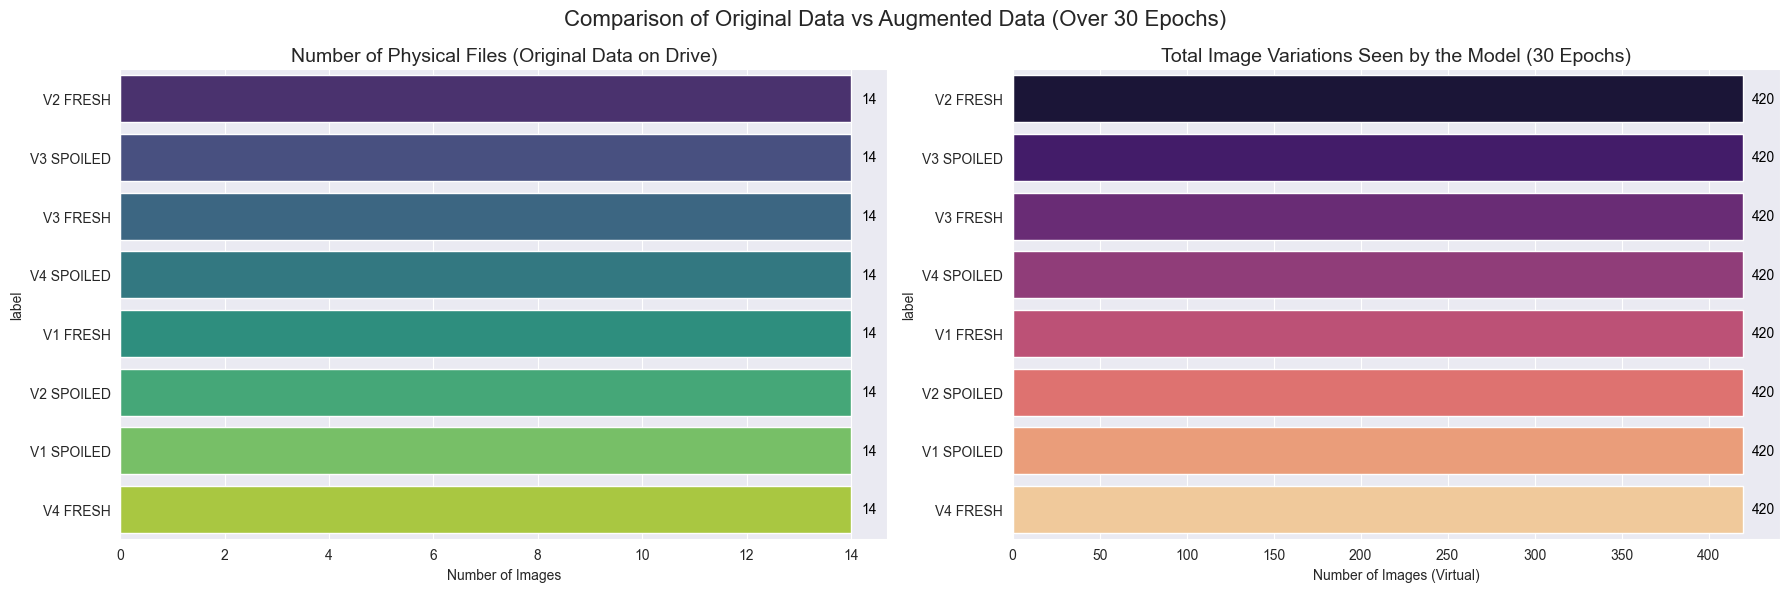


--- EXPLANATION ---
1. Total Original Training Files: 112 images.
2. Since augmentation happens every epoch, over 30 epochs the model will learn from:
   112 x 30 = 3360 different image variations.
3. This is why augmentation is very effective at preventing overfitting even when the original dataset is small.


In [10]:


def visualize_data_expansion(train_df, epochs=30):
    # Count original (physical) data
    original_counts = train_df['label'].value_counts()
    
    # Count virtual data (Original Data x Number of Epochs)
    virtual_counts = original_counts * epochs
    
    classes = original_counts.index
    
    # Plot setup
    fig, ax = plt.subplots(1, 2, figsize=(18, 6))
    
    # Plot 1: Physical (Real) Data
    # FIX: Add hue=classes and legend=False
    sns.barplot(
        x=original_counts.values, y=classes,
        hue=classes, legend=False,
        ax=ax[0], palette='viridis'
    )
    
    ax[0].set_title('Number of Physical Files (Original Data on Drive)', fontsize=14)
    ax[0].set_xlabel('Number of Images')
    for i, v in enumerate(original_counts.values):
        ax[0].text(v + 0.2, i, str(v), color='black', va='center')

    # Plot 2: Virtual Data (Seen by the Model)
    # FIX: Add hue=classes and legend=False
    sns.barplot(
        x=virtual_counts.values, y=classes,
        hue=classes, legend=False,
        ax=ax[1], palette='magma'
    )
    
    ax[1].set_title(f'Total Image Variations Seen by the Model ({epochs} Epochs)', fontsize=14)
    ax[1].set_xlabel('Number of Images (Virtual)')
    for i, v in enumerate(virtual_counts.values):
        ax[1].text(v + 5, i, f"{v:,}", color='black', va='center')  # Thousands format

    plt.suptitle(
        f"Comparison of Original Data vs Augmented Data (Over {epochs} Epochs)",
        fontsize=16
    )
    plt.tight_layout()
    plt.show()
    
    print(f"\n--- EXPLANATION ---")
    print(f"1. Total Original Training Files: {len(train_df)} images.")
    print(f"2. Since augmentation happens every epoch, over {epochs} epochs the model will learn from:")
    print(f"   {len(train_df)} x {epochs} = {len(train_df)*epochs} different image variations.")
    print("3. This is why augmentation is very effective at preventing overfitting even when the original dataset is small.")

# Run the visualization
visualize_data_expansion(train_df, epochs=30)


## TRAINING DATA

In [11]:
# ==========================================
# 4. FUNGSI UTAMA (TRAIN, SAVE, EVALUATE)
# ==========================================
def run_experiment(model, exp_name, epochs=100):
    print(f"\n{'='*15} MULAI: {exp_name} {'='*15}")
    print("Training Device:", tf.test.gpu_device_name() if tf.test.is_gpu_available() else "CPU")
    # 1. Checkpoint: Simpan model terbaik (Best Weights) ke file .keras
    checkpoint_path = f"{exp_name}_best_model.keras"
    checkpoint = callbacks.ModelCheckpoint(
        checkpoint_path, 
        monitor='val_loss', 
        save_best_only=True, 
        mode='min', 
        verbose=1
    )
    
    # 2. Early Stopping: Berhenti jika tidak ada perbaikan
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
    
    # 3. Reduce LR: Kurangi learning rate jika stagnan
    lr_schedule = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    
    # 4. CSV Logger
    csv_log = callbacks.CSVLogger(f'{exp_name}_training_log.csv')
    
    # --- TRAINING ---
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=[checkpoint, early_stop, lr_schedule, csv_log],
        verbose=1
    )
    
    # Simpan model versi terakhir (opsional, backup)
    model.save(f"{exp_name}_final_model.keras")
    print(f"Model berhasil disimpan sebagai: {checkpoint_path}")
    
    return history

def evaluate_and_plot(model, history, exp_name):
    # --- PLOT GRAFIK ---
    metrics_df = pd.DataFrame(history.history)
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # Grafik Akurasi
    sns.lineplot(data=metrics_df[['accuracy', 'val_accuracy']], ax=ax[0])
    ax[0].set_title(f'{exp_name}: Accuracy')
    
    # Grafik Loss
    sns.lineplot(data=metrics_df[['loss', 'val_loss']], ax=ax[1])
    ax[1].set_title(f'{exp_name}: Loss')
    plt.show()

    # --- EVALUASI TEST SET ---
    print(f"\n--- Evaluasi pada Data Test: {exp_name} ---")
    predictions = model.predict(test_gen)
    y_pred = np.argmax(predictions, axis=1)
    y_true = test_gen.classes

    # Classification Report
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predict')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.title(f'Confusion Matrix: {exp_name}')
    plt.show()
    
input_shape = (IMG_SIZE[0], IMG_SIZE[1], 3)
num_classes = len(class_names)

In [12]:
from tensorflow.keras.applications import DenseNet121

In [13]:
def create_densenet():
    # Load Pre-trained (tanpa bagian atas/head)
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Freeze bobot awal (Feature Extraction)
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(), # Menstabilkan training
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),         # Mencegah overfitting agresif
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


=============== MULAI: Exp1_DenseNet121_Dengan_Lempuk_2 ===============
Training Device: CPU
Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1566 - loss: 2.4914
Epoch 1: val_loss improved from inf to 1.70843, saving model to Exp1_DenseNet121_Dengan_Lempuk_2_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.1610 - loss: 2.4692 - val_accuracy: 0.3750 - val_loss: 1.7084 - learning_rate: 0.0010
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2631 - loss: 1.9410
Epoch 2: val_loss improved from 1.70843 to 1.42789, saving model to Exp1_DenseNet121_Dengan_Lempuk_2_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.2801 - loss: 1.8889 - val_accuracy: 0.5625 - val_loss: 1.4279 - learning_rate: 0.0010
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6252 - loss: 1.2368
Epoch 3: val_loss improved from 1.42789 to 1.26538, saving model to Exp1_DenseNet121_Dengan_Lempuk_2_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step

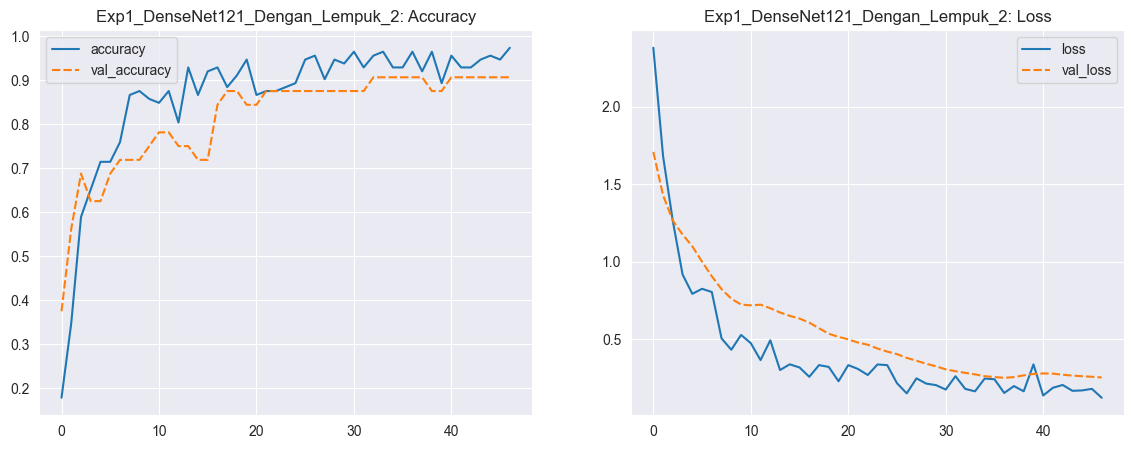


--- Evaluasi pada Data Test: Exp1_DenseNet121_Dengan_Lempuk_2 ---


C:\Users\Azvaden\Desktop\mataikansegar-densenet121\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
              precision    recall  f1-score   support

    V1 FRESH       1.00      0.50      0.67         2
  V1 SPOILED       1.00      1.00      1.00         2
    V2 FRESH       1.00      1.00      1.00         2
  V2 SPOILED       1.00      1.00      1.00         2
    V3 FRESH       0.67      1.00      0.80         2
  V3 SPOILED       1.00      1.00      1.00         2
    V4 FRESH       1.00      1.00      1.00         2
  V4 SPOILED       1.00      1.00      1.00         2

    accuracy                           0.94        16
   macro avg       0.96      0.94      0.93        16
weighted avg       0.96      0.94      0.93        16



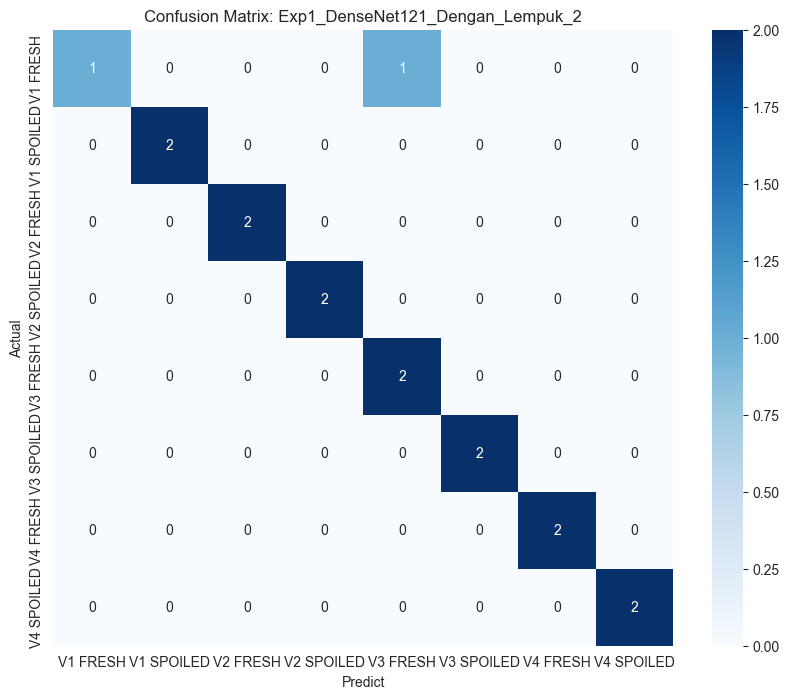

In [39]:
# Eksekusi Exp 4
model_4 = create_densenet()
hist_4 = run_experiment(model_4, "Exp1_DenseNet121_Dengan_Lempuk_2", epochs=200)
evaluate_and_plot(model_4, hist_4, "Exp1_DenseNet121_Dengan_Lempuk_2")

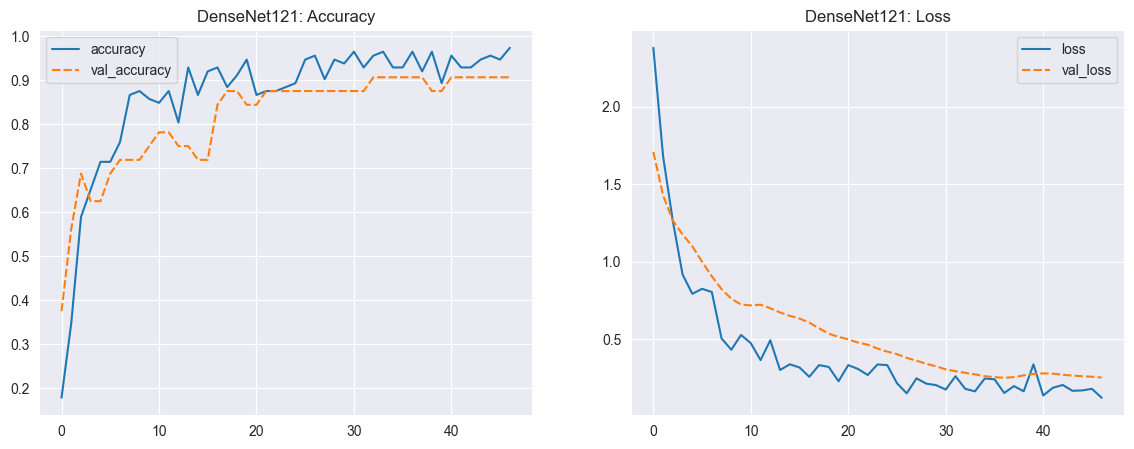


--- Evaluasi pada Data Test: DenseNet121 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
              precision    recall  f1-score   support

    V1 FRESH       1.00      0.50      0.67         2
  V1 SPOILED       1.00      1.00      1.00         2
    V2 FRESH       1.00      1.00      1.00         2
  V2 SPOILED       1.00      1.00      1.00         2
    V3 FRESH       0.67      1.00      0.80         2
  V3 SPOILED       1.00      1.00      1.00         2
    V4 FRESH       1.00      1.00      1.00         2
  V4 SPOILED       1.00      1.00      1.00         2

    accuracy                           0.94        16
   macro avg       0.96      0.94      0.93        16
weighted avg       0.96      0.94      0.93        16



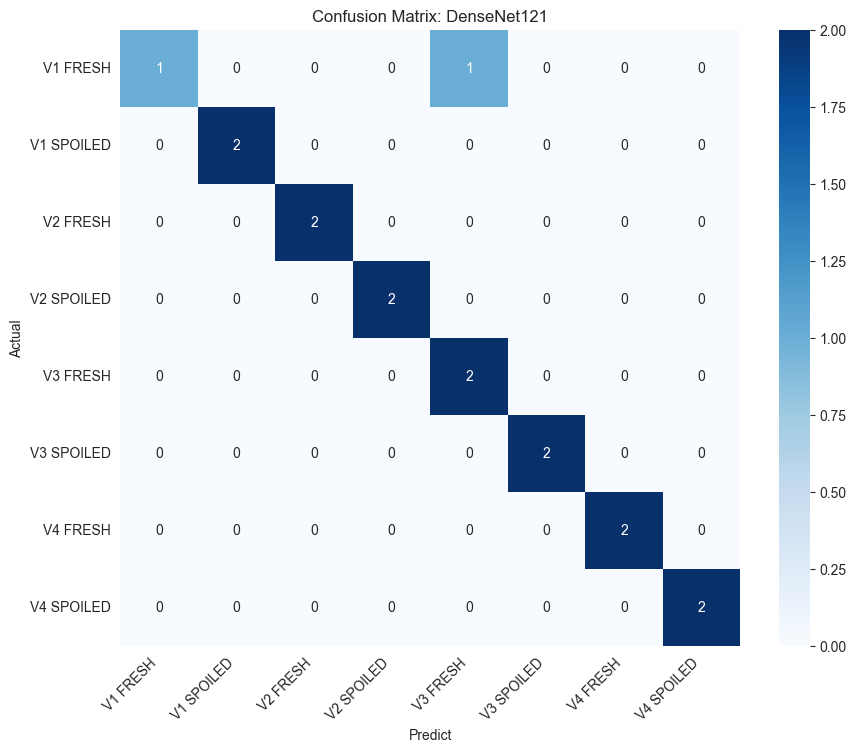

In [42]:
evaluate_and_plot(model_4, hist_4, "DenseNet121")

# K-FOld


=============== MULAI 5-FOLD CROSS-VALIDATION ===============

------------ Fold 1/5 ------------
Train      : 102
Validation : 26
Testing    : 32
Found 102 validated image filenames belonging to 8 classes.
Found 26 validated image filenames belonging to 8 classes.
Found 32 validated image filenames belonging to 8 classes.


C:\Users\Azvaden\Desktop\edible-densenet121\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1961 - loss: 2.6494
Epoch 1: val_loss improved from inf to 2.18897, saving model to kfold_fold_1_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - accuracy: 0.1941 - loss: 2.6357 - val_accuracy: 0.1538 - val_loss: 2.1890 - learning_rate: 0.0010
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3642 - loss: 1.9131
Epoch 2: val_loss improved from 2.18897 to 1.72973, saving model to kfold_fold_1_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.3679 - loss: 1.8949 - val_accuracy: 0.3462 - val_loss: 1.7297 - learning_rate: 0.0010
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5464 - loss: 1.2253
Epoch 3: val_loss improved from 1.72973 to 1.51737, saving model to kfold_fold_1_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.5430 - loss: 1.2404 - val_accuracy: 0.3462 - val_loss: 1.5174 - learning_rate: 0.0010
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc

C:\Users\Azvaden\Desktop\edible-densenet121\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1194 - loss: 2.4884
Epoch 1: val_loss improved from inf to 2.04740, saving model to kfold_fold_2_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step - accuracy: 0.1308 - loss: 2.4551 - val_accuracy: 0.2308 - val_loss: 2.0474 - learning_rate: 0.0010
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2609 - loss: 1.9735
Epoch 2: val_loss improved from 2.04740 to 1.84115, saving model to kfold_fold_2_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.2793 - loss: 1.9258 - val_accuracy: 0.3462 - val_loss: 1.8412 - learning_rate: 0.0010
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4230 - loss: 1.3731
Epoch 3: val_loss improved from 1.84115 to 1.62456, saving model to kfold_fold_2_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.4404 - loss: 1.3552 - val_accuracy: 0.4615 - val_loss: 1.6246 - learning_rate: 0.0010
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc

...

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2749 - loss: 2.2592
Epoch 1: val_loss improved from inf to 1.94243, saving model to kfold_fold_3_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step - accuracy: 0.2709 - loss: 2.2631 - val_accuracy: 0.4231 - val_loss: 1.9424 - learning_rate: 0.0010
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3337 - loss: 1.8690
Epoch 2: val_loss improved from 1.94243 to 1.67152, saving model to kfold_fold_3_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.3395 - loss: 1.8639 - val_accuracy: 0.5000 - val_loss: 1.6715 - learning_rate: 0.0010
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4498 - loss: 1.3165
Epoch 3: val_loss improved from 1.67152 to 1.48304, saving model to kfold_fold_3_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.4520 - loss: 1.3080 - val_accuracy: 0.5000 - val_loss: 1.4830 - learning_rate: 0.0010
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc

C:\Users\Azvaden\Desktop\edible-densenet121\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1614 - loss: 2.4789
Epoch 1: val_loss improved from inf to 2.07118, saving model to kfold_fold_4_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.1703 - loss: 2.4398 - val_accuracy: 0.3077 - val_loss: 2.0712 - learning_rate: 0.0010
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3479 - loss: 1.9389
Epoch 2: val_loss improved from 2.07118 to 1.81236, saving model to kfold_fold_4_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.3509 - loss: 1.9169 - val_accuracy: 0.3462 - val_loss: 1.8124 - learning_rate: 0.0010
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5585 - loss: 1.4794
Epoch 3: val_loss improved from 1.81236 to 1.51554, saving model to kfold_fold_4_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.5566 - loss: 1.4714 - val_accuracy: 0.5000 - val_loss: 1.5155 - learning_rate: 0.0010
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc

C:\Users\Azvaden\Desktop\edible-densenet121\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1194 - loss: 2.4297
Epoch 1: val_loss improved from inf to 2.18075, saving model to kfold_fold_5_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.1210 - loss: 2.4220 - val_accuracy: 0.0769 - val_loss: 2.1807 - learning_rate: 0.0010
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3104 - loss: 1.8429
Epoch 2: val_loss improved from 2.18075 to 1.89445, saving model to kfold_fold_5_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.3091 - loss: 1.8430 - val_accuracy: 0.1538 - val_loss: 1.8944 - learning_rate: 0.0010
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3930 - loss: 1.5400
Epoch 3: val_loss improved from 1.89445 to 1.76032, saving model to kfold_fold_5_best_model.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.3889 - loss: 1.5399 - val_accuracy: 0.1538 - val_loss: 1.7603 - learning_rate: 0.0010
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc

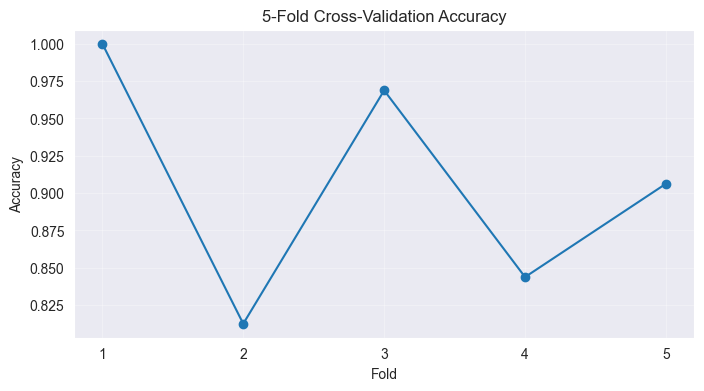

In [15]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from tensorflow.keras import backend as K

def make_generators_from_dataframe(train_df, val_df, test_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE, classes=None):
    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col='filepath',
        y_col='label',
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        classes=classes,
        shuffle=True
    )

    val_gen = val_test_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col='filepath',
        y_col='label',
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        classes=classes,
        shuffle=False
    )

    test_gen = val_test_datagen.flow_from_dataframe(
        dataframe=test_df,
        x_col='filepath',
        y_col='label',
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        classes=classes,
        shuffle=False
    )

    return train_gen, val_gen, test_gen


def run_kfold_cross_validation(
    dataframe,
    build_model_fn,
    n_splits=5,
    epochs=50,
    batch_size=BATCH_SIZE,
    random_state=42,
    validation_size=0.2
):
    dataframe = dataframe.copy().reset_index(drop=True)

    # Pastikan urutan kelas konsisten di semua fold
    class_names = sorted(dataframe['label'].unique())
    num_classes = len(class_names)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_results = []

    print(f"\n{'='*15} MULAI {n_splits}-FOLD CROSS-VALIDATION {'='*15}")

    for fold_no, (train_val_idx, test_idx) in enumerate(
        skf.split(dataframe['filepath'], dataframe['label']), start=1
    ):
        print(f"\n{'-'*12} Fold {fold_no}/{n_splits} {'-'*12}")

        # 1 fold sebagai testing, sisanya sebagai train+validation
        train_val_df = dataframe.iloc[train_val_idx].reset_index(drop=True)
        test_df = dataframe.iloc[test_idx].reset_index(drop=True)

        # Validation internal dari data training fold
        train_df, val_df = train_test_split(
            train_val_df,
            test_size=validation_size,
            stratify=train_val_df['label'],
            random_state=random_state
        )

        print(f"Train      : {len(train_df)}")
        print(f"Validation : {len(val_df)}")
        print(f"Testing    : {len(test_df)}")

        train_gen, val_gen, test_gen = make_generators_from_dataframe(
            train_df=train_df,
            val_df=val_df,
            test_df=test_df,
            img_size=IMG_SIZE,
            batch_size=batch_size,
            classes=class_names
        )

        # Reset session agar model fold sebelumnya tidak menumpuk di memori
        K.clear_session()

        # Sesuaikan variabel global yang dipakai create_densenet()
        globals()['class_names'] = class_names
        globals()['num_classes'] = num_classes

        model = build_model_fn()

        checkpoint_path = f"kfold_fold_{fold_no}_best_model.keras"
        checkpoint = callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor='val_loss',
            save_best_only=True,
            mode='min',
            verbose=1
        )

        early_stop = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        )

        lr_schedule = callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            verbose=1
        )

        csv_log = callbacks.CSVLogger(f'kfold_fold_{fold_no}_training_log.csv')

        history = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=epochs,
            callbacks=[checkpoint, early_stop, lr_schedule, csv_log],
            verbose=1
        )

        # Gunakan model terbaik pada fold tersebut
        best_model = tf.keras.models.load_model(checkpoint_path)

        test_loss, test_accuracy = best_model.evaluate(test_gen, verbose=0)
        print(f"Accuracy Fold-{fold_no}: {test_accuracy:.4f}")

        fold_results.append({
            'fold': fold_no,
            'train_samples': len(train_df),
            'val_samples': len(val_df),
            'test_samples': len(test_df),
            'accuracy': test_accuracy,
            'loss': test_loss,
            'best_epoch': int(np.argmin(history.history['val_loss']) + 1)
        })

    results_df = pd.DataFrame(fold_results)

    mean_accuracy = results_df['accuracy'].mean()
    std_accuracy = results_df['accuracy'].std(ddof=1) if len(results_df) > 1 else 0.0

    print(f"\n{'='*15} HASIL AKHIR K-FOLD {'='*15}")
    print(results_df[['fold', 'accuracy', 'loss', 'best_epoch']])
    print(f"\nMean Accuracy      : {mean_accuracy:.4f}")
    print(f"Standard Deviation : {std_accuracy:.4f}")

    plt.figure(figsize=(8, 4))
    plt.plot(results_df['fold'], results_df['accuracy'], marker='o')
    plt.xticks(results_df['fold'])
    plt.xlabel('Fold')
    plt.ylabel('Accuracy')
    plt.title(f'{n_splits}-Fold Cross-Validation Accuracy')
    plt.grid(True, alpha=0.3)
    plt.show()

    return results_df, mean_accuracy, std_accuracy


# Contoh eksekusi K-Fold
kfold_results, mean_accuracy, std_accuracy = run_kfold_cross_validation(
    dataframe=df,
    build_model_fn=create_densenet,
    n_splits=5,      # ganti 10 jika ingin 10-Fold
    epochs=150,
    batch_size=BATCH_SIZE,
    random_state=42,
    validation_size=0.2
)

In [16]:
print(f"\n{'='*15} Final Relust K-FOLD {'='*15}")
print(kfold_results[['fold', 'accuracy', 'loss', 'best_epoch']])
print(f"\nMean Accuracy      : {mean_accuracy:.4f}")
print(f"Standard Deviation : {std_accuracy:.4f}")


=============== Final Relust K-FOLD ===============
   fold  accuracy      loss  best_epoch
0     1   1.00000  0.080232         150
1     2   0.81250  0.554044          81
2     3   0.96875  0.196254          99
3     4   0.84375  0.616960          24
4     5   0.90625  0.309930         148

Mean Accuracy      : 0.9062
Standard Deviation : 0.0797


In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# =========================================================
# 1. GENERATOR UNTUK TEST SET PER FOLD
# =========================================================
def make_test_generator_from_dataframe(test_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE, classes=None):
    test_gen = val_test_datagen.flow_from_dataframe(
        dataframe=test_df,
        x_col='filepath',
        y_col='label',
        target_size=img_size,
        batch_size=batch_size,
        class_mode='categorical',
        classes=classes,
        shuffle=False
    )
    return test_gen


# =========================================================
# 2. EVALUASI MODEL K-FOLD YANG SUDAH DISIMPAN
# =========================================================
def evaluate_saved_kfold_models(
    dataframe,
    n_splits=5,
    random_state=42,
    batch_size=BATCH_SIZE,
    model_pattern="kfold_fold_{fold}_best_model.keras",
    csv_pattern="kfold_fold_{fold}_training_log.csv"
):
    dataframe = dataframe.copy().reset_index(drop=True)
    class_names = sorted(dataframe['label'].unique())

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_results = []
    histories = []

    all_true_labels = []
    all_pred_labels = []
    all_pred_probs = []

    print(f"{'='*15} EVALUATION {n_splits}-FOLD {'='*15}")

    for fold_no, (_, test_idx) in enumerate(skf.split(dataframe['filepath'], dataframe['label']), start=1):
        print(f"\n{'-'*12} Fold {fold_no}/{n_splits} {'-'*12}")

        model_path = model_pattern.format(fold=fold_no)
        csv_path   = csv_pattern.format(fold=fold_no)

        if not os.path.exists(model_path):
            print(f"Model fold-{fold_no} tidak ditemukan: {model_path}")
            continue

        test_df = dataframe.iloc[test_idx].reset_index(drop=True)
        test_gen = make_test_generator_from_dataframe(
            test_df=test_df,
            img_size=IMG_SIZE,
            batch_size=batch_size,
            classes=class_names
        )

        model = tf.keras.models.load_model(model_path)

        test_loss, test_accuracy = model.evaluate(test_gen, verbose=0)
        print(f"Test samples      : {len(test_df)}")
        print(f"Test accuracy     : {test_accuracy:.4f}")
        print(f"Test loss         : {test_loss:.4f}")

        test_gen.reset()
        y_prob = model.predict(test_gen, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        y_true = test_gen.classes

        all_true_labels.extend(y_true)
        all_pred_labels.extend(y_pred)
        all_pred_probs.extend(y_prob)

        best_epoch = None
        best_val_loss = None
        best_val_acc = None
        history_df = None

        if os.path.exists(csv_path):
            history_df = pd.read_csv(csv_path)

            if 'epoch' not in history_df.columns:
                history_df['epoch'] = range(1, len(history_df) + 1)
            else:
                history_df['epoch'] = history_df['epoch'] + 1

            histories.append({
                'fold': fold_no,
                'history_df': history_df
            })

            if 'val_loss' in history_df.columns:
                best_epoch_idx = history_df['val_loss'].idxmin()
                best_epoch = int(history_df.loc[best_epoch_idx, 'epoch'])
                best_val_loss = float(history_df.loc[best_epoch_idx, 'val_loss'])

                if 'val_accuracy' in history_df.columns:
                    best_val_acc = float(history_df.loc[best_epoch_idx, 'val_accuracy'])

        fold_results.append({
            'fold': fold_no,
            'test_samples': len(test_df),
            'accuracy': test_accuracy,
            'loss': test_loss,
            'best_epoch': best_epoch,
            'best_val_loss': best_val_loss,
            'best_val_accuracy': best_val_acc,
            'model_path': model_path,
            'csv_path': csv_path if os.path.exists(csv_path) else None
        })

    results_df = pd.DataFrame(fold_results)

    if len(results_df) == 0:
        raise ValueError("Tidak ada model fold yang berhasil dibaca. Cek nama file dan pattern-nya.")

    mean_accuracy = results_df['accuracy'].mean()
    std_accuracy = results_df['accuracy'].std(ddof=1) if len(results_df) > 1 else 0.0
    mean_loss = results_df['loss'].mean()
    std_loss = results_df['loss'].std(ddof=1) if len(results_df) > 1 else 0.0

    print(f"\n{'='*15} SUMMARY RESULT K-FOLD {'='*15}")
    print(results_df[['fold', 'accuracy', 'loss', 'best_epoch']])
    print(f"\nMean Accuracy      : {mean_accuracy:.4f}")
    print(f"Standard Deviation : {std_accuracy:.4f}")
    print(f"Mean Loss          : {mean_loss:.4f}")
    print(f"Std Loss           : {std_loss:.4f}")

    outputs = {
        'results_df': results_df,
        'histories': histories,
        'class_names': class_names,
        'all_true_labels': np.array(all_true_labels),
        'all_pred_labels': np.array(all_pred_labels),
        'all_pred_probs': np.array(all_pred_probs),
        'mean_accuracy': mean_accuracy,
        'std_accuracy': std_accuracy,
        'mean_loss': mean_loss,
        'std_loss': std_loss
    }

    return outputs

In [26]:
def plot_saved_kfold_report(cv_outputs):
    results_df = cv_outputs['results_df']
    histories = cv_outputs['histories']
    class_names = cv_outputs['class_names']
    y_true = cv_outputs['all_true_labels']
    y_pred = cv_outputs['all_pred_labels']
    y_prob = cv_outputs['all_pred_probs']
    mean_accuracy = cv_outputs['mean_accuracy']
    std_accuracy = cv_outputs['std_accuracy']
    mean_loss = cv_outputs['mean_loss']
    std_loss = cv_outputs['std_loss']

    # =====================================================
    # 1. Accuracy per Fold
    # =====================================================
    plt.figure(figsize=(8, 5))
    plt.plot(results_df['fold'], results_df['accuracy'], marker='o')
    plt.axhline(mean_accuracy, linestyle='--', label=f'Mean = {mean_accuracy:.4f}')
    plt.xticks(results_df['fold'])
    plt.xlabel('Fold')
    plt.ylabel('Accuracy')
    plt.title('Accuracy per Fold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # =====================================================
    # 2. Loss per Fold
    # =====================================================
    plt.figure(figsize=(8, 5))
    plt.plot(results_df['fold'], results_df['loss'], marker='o')
    plt.axhline(mean_loss, linestyle='--', label=f'Mean = {mean_loss:.4f}')
    plt.xticks(results_df['fold'])
    plt.xlabel('Fold')
    plt.ylabel('Loss')
    plt.title('Loss per Fold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # =====================================================
    # 3. Bar Chart Accuracy per Fold
    # =====================================================
    plt.figure(figsize=(8, 5))
    plt.bar(results_df['fold'].astype(str), results_df['accuracy'])
    plt.xlabel('Fold')
    plt.ylabel('Accuracy')
    plt.title('Bar Chart Accuracy per Fold')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # =====================================================
    # 4. Mean Accuracy ± Std
    # =====================================================
    plt.figure(figsize=(5, 5))
    plt.bar(['K-Fold'], [mean_accuracy], yerr=[std_accuracy], capsize=10)
    plt.ylabel('Accuracy')
    plt.title('Mean Accuracy ± Standard Deviation')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # =====================================================
    # 5. Kurva Training/Validation Accuracy dari CSV tiap fold
    # =====================================================
    plt.figure(figsize=(10, 6))
    ada_kurva = False
    for item in histories:
        fold_no = item['fold']
        hist = item['history_df']

        if 'accuracy' in hist.columns and 'val_accuracy' in hist.columns:
            plt.plot(hist['epoch'], hist['accuracy'], label=f'Train Fold-{fold_no}')
            plt.plot(hist['epoch'], hist['val_accuracy'], linestyle='--', label=f'Val Fold-{fold_no}')
            ada_kurva = True

    if ada_kurva:
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Curva Training and Validation Accuracy per Fold')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Kolom accuracy/val_accuracy tidak ditemukan di file CSV.")

    # =====================================================
    # 6. Kurva Training/Validation Loss dari CSV tiap fold
    # =====================================================
    plt.figure(figsize=(10, 6))
    ada_kurva = False
    for item in histories:
        fold_no = item['fold']
        hist = item['history_df']

        if 'loss' in hist.columns and 'val_loss' in hist.columns:
            plt.plot(hist['epoch'], hist['loss'], label=f'Train Fold-{fold_no}')
            plt.plot(hist['epoch'], hist['val_loss'], linestyle='--', label=f'Val Fold-{fold_no}')
            ada_kurva = True

    if ada_kurva:
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Curva Training and Validation Loss per Fold')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Kolom loss/val_loss tidak ditemukan di file CSV.")

    # =====================================================
    # 7. Confusion Matrix gabungan semua fold
    # =====================================================
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title('Aggregated Confusion Matrix')
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha='right')
    plt.yticks(tick_marks, class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.ylabel('Label Asli')
    plt.xlabel('Label Prediksi')
    plt.tight_layout()
    plt.show()

    # =====================================================
    # 8. Classification Report
    # =====================================================
    print("=== Aggregated Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names))

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True
    )
    report_df = pd.DataFrame(report_dict).transpose()
    display(report_df)

    # =====================================================
    # 9. ROC Curve
    # =====================================================
    n_classes = len(class_names)

    if n_classes == 2:
        fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(7, 6))
        plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    else:
        y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

        plt.figure(figsize=(8, 6))
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve per Class')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # =====================================================
    # 10. Ringkasan
    # =====================================================
    print("=== RESUME K-FOLD ===")
    print(f"Mean Accuracy      : {mean_accuracy:.4f}")
    print(f"Standard Deviation : {std_accuracy:.4f}")
    print(f"Mean Loss          : {mean_loss:.4f}")
    print(f"Std Loss           : {std_loss:.4f}")

=============== EVALUATION 5-FOLD ===============

------------ Fold 1/5 ------------
Found 32 validated image filenames belonging to 8 classes.


C:\Users\Azvaden\Desktop\edible-densenet121\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Test samples      : 32
Test accuracy     : 1.0000
Test loss         : 0.0802

------------ Fold 2/5 ------------
Found 32 validated image filenames belonging to 8 classes.


C:\Users\Azvaden\Desktop\edible-densenet121\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Test samples      : 32
Test accuracy     : 0.8125
Test loss         : 0.5540

------------ Fold 3/5 ------------
Found 32 validated image filenames belonging to 8 classes.


...

Test samples      : 32
Test accuracy     : 0.9688
Test loss         : 0.1963

------------ Fold 4/5 ------------
Found 32 validated image filenames belonging to 8 classes.


C:\Users\Azvaden\Desktop\edible-densenet121\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Test samples      : 32
Test accuracy     : 0.8438
Test loss         : 0.6170

------------ Fold 5/5 ------------
Found 32 validated image filenames belonging to 8 classes.


C:\Users\Azvaden\Desktop\edible-densenet121\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Test samples      : 32
Test accuracy     : 0.9062
Test loss         : 0.3099

=============== SUMMARY RESULT K-FOLD ===============
   fold  accuracy      loss  best_epoch
0     1   1.00000  0.080232         150
1     2   0.81250  0.554044          81
2     3   0.96875  0.196254          99
3     4   0.84375  0.616960          24
4     5   0.90625  0.309930         148

Mean Accuracy      : 0.9062
Standard Deviation : 0.0797
Mean Loss          : 0.3515
Std Loss           : 0.2296


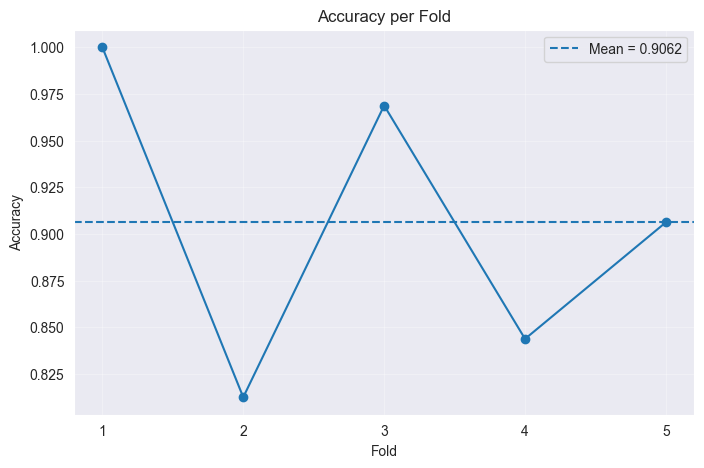

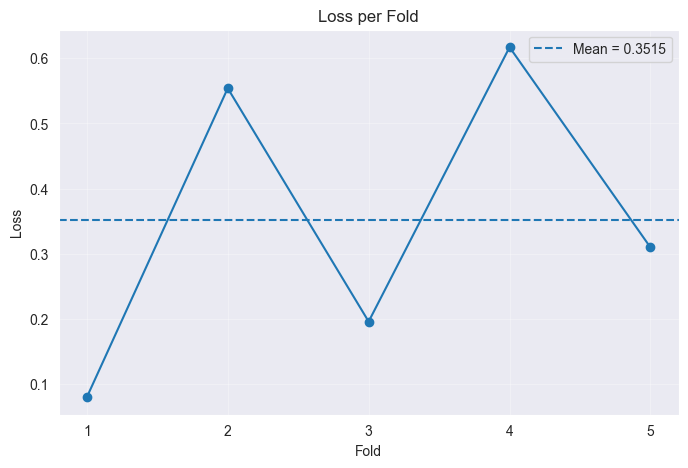

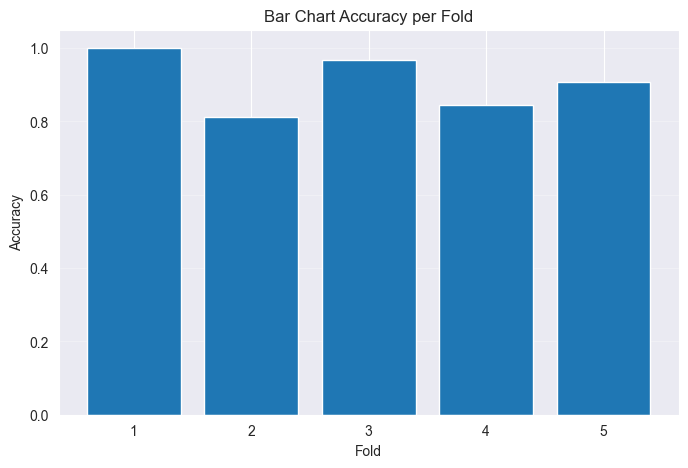

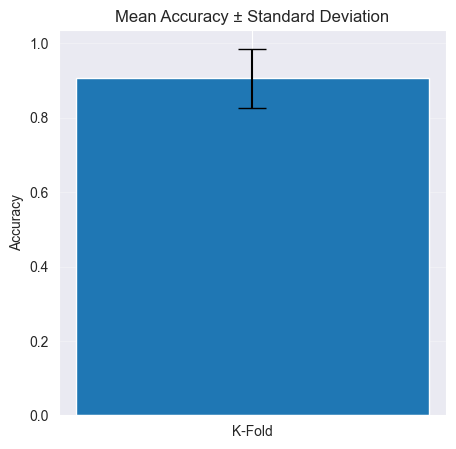

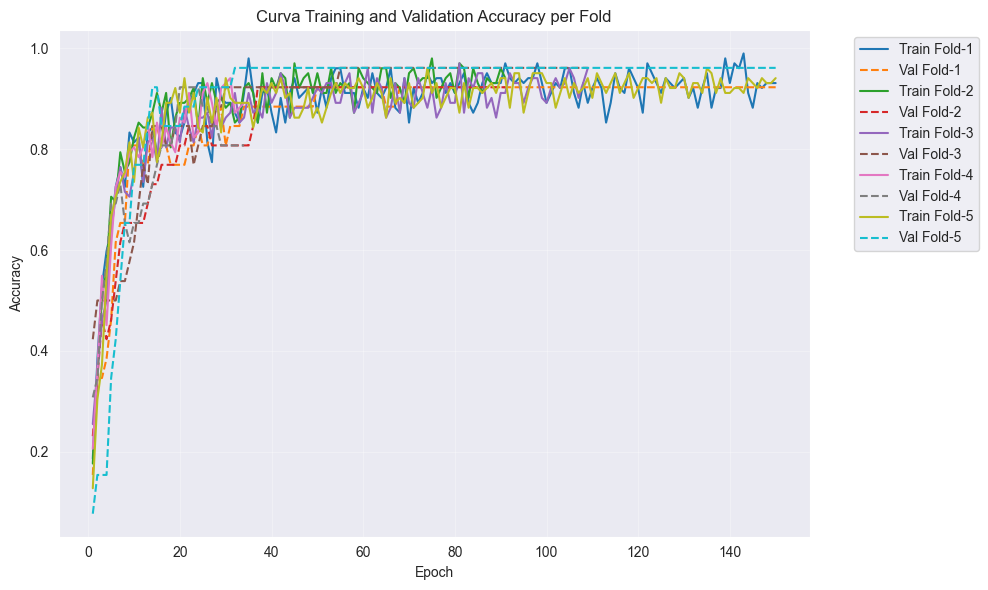

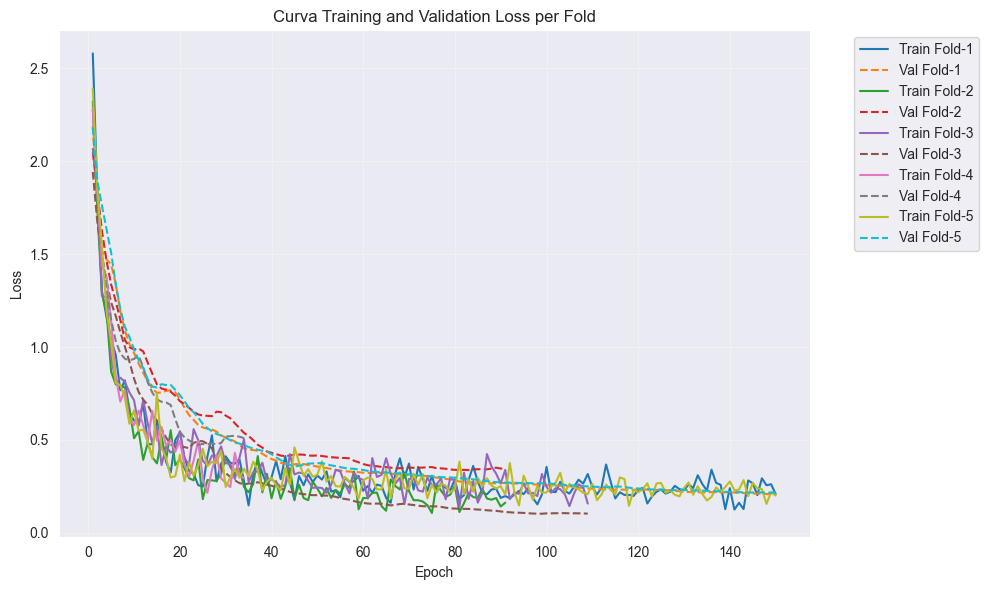

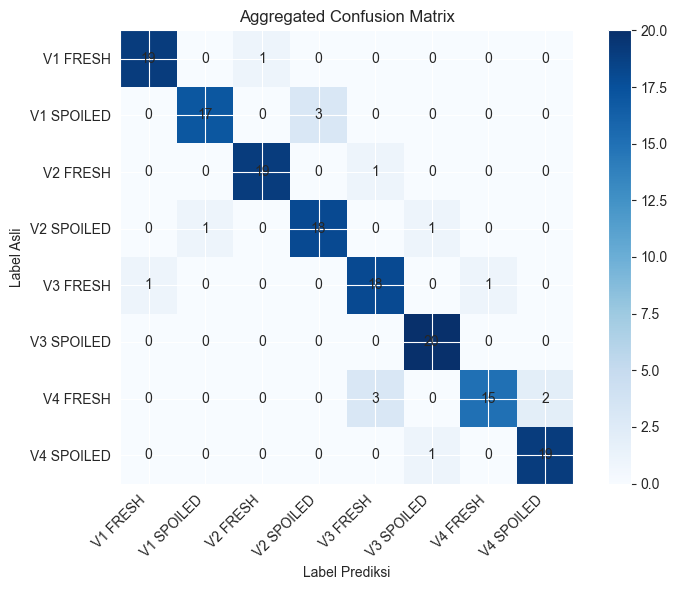

=== Aggregated Classification Report ===
              precision    recall  f1-score   support

    V1 FRESH       0.95      0.95      0.95        20
  V1 SPOILED       0.94      0.85      0.89        20
    V2 FRESH       0.95      0.95      0.95        20
  V2 SPOILED       0.86      0.90      0.88        20
    V3 FRESH       0.82      0.90      0.86        20
  V3 SPOILED       0.91      1.00      0.95        20
    V4 FRESH       0.94      0.75      0.83        20
  V4 SPOILED       0.90      0.95      0.93        20

    accuracy                           0.91       160
   macro avg       0.91      0.91      0.91       160
weighted avg       0.91      0.91      0.91       160



,precision,recall,f1-score,support
V1 FRESH,0.950000,0.95000,0.950000,20.00000
V1 SPOILED,0.944444,0.85000,0.894737,20.00000
V2 FRESH,0.950000,0.95000,0.950000,20.00000
V2 SPOILED,0.857143,0.90000,0.878049,20.00000
V3 FRESH,0.818182,0.90000,0.857143,20.00000
V3 SPOILED,0.909091,1.00000,0.952381,20.00000
V4 FRESH,0.937500,0.75000,0.833333,20.00000
V4 SPOILED,0.904762,0.95000,0.926829,20.00000
accuracy,0.906250,0.90625,0.906250,0.90625
macro avg,0.908890,0.90625,0.905309,160.00000


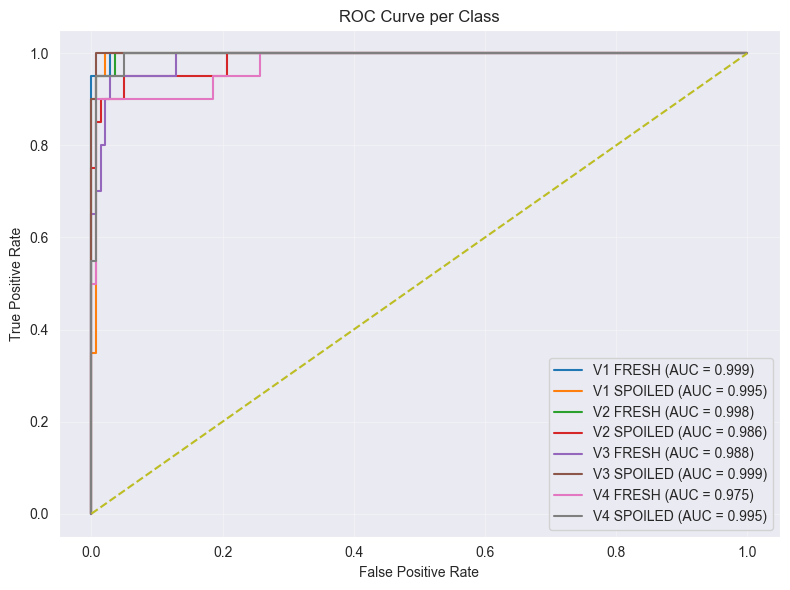

=== RESUME K-FOLD ===
Mean Accuracy      : 0.9062
Standard Deviation : 0.0797
Mean Loss          : 0.3515
Std Loss           : 0.2296


In [27]:
cv_outputs = evaluate_saved_kfold_models(
    dataframe=df,
    n_splits=5,
    random_state=42,
    batch_size=BATCH_SIZE,
    model_pattern="kfold_fold_{fold}_best_model.keras",
    csv_pattern="kfold_fold_{fold}_training_log.csv"
)

plot_saved_kfold_report(cv_outputs)